# PINNs + Poisson + Last-Layer Laplace

This notebook introduces physics-informed neural networks on Poisson problems.
We use a short 1D warm-up and then a 2D main example with sparse supervised
anchor points plus physics residual training. Uncertainty is quantified with a
last-layer Laplace approximation over the sparse anchors.

This version tightens the 2D workflow in four ways:

1. the 2D anchor set now includes substantially more interior supervision,
2. the PINN is trained with an `Adam -> LBFGS` schedule instead of Adam alone,
3. the Laplace fit uses a stronger `prior_precision` so posterior samples stay
   close to the trained MAP PINN,
4. the notebook compares `diag` and `block_diag` last-layer curvature on the
   same trained network before choosing a default uncertainty view.

Primary references:

- Raissi, Perdikaris, Karniadakis (2019), *Physics-informed neural networks*
- MacKay (1992), *A Practical Bayesian Framework for Backpropagation Networks*
- Ritter, Botev, Barber (2018), *A Scalable Laplace Approximation for Neural Networks*
- Daxberger et al. (2021), *Laplace Redux: Effortless Bayesian Deep Learning*

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / 'src').exists():
    repo_root = repo_root.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import LaplaceWrapper
from deepuq.models import PINN1D, PINN2D

torch.manual_seed(23)
np.random.seed(23)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cpu


## 1D warm-up

We solve

$$
-u''(x)=\pi^2\sin(\pi x),\qquad u(0)=u(1)=0,
$$

whose exact solution is $u(x)=\sin(\pi x)$.

The warm-up uses the same training logic as the 2D case:

- an Adam phase to get into the right basin,
- an LBFGS phase to polish the PDE-constrained optimum,
- light interior anchors to keep the solution aligned with the analytic target.


In [2]:
x_bc = torch.tensor([[0.0], [1.0]])
y_bc = torch.zeros(2, 1)
x_anchor = torch.linspace(0.1, 0.9, 16).unsqueeze(-1)
y_anchor = torch.sin(math.pi * x_anchor)

pinn1d = PINN1D(hidden_dims=(64, 64, 64)).to(device)
adam_1d = torch.optim.Adam(pinn1d.parameters(), lr=1e-3)
history_1d = []

for step in range(800):
    adam_1d.zero_grad(set_to_none=True)
    # Resample collocation points every Adam step so the PDE residual is not tied
    # to a single fixed discretization of the interior.
    x_c = torch.rand(128, 1, device=device, requires_grad=True)
    u = pinn1d(x_c)
    du = torch.autograd.grad(u.sum(), x_c, create_graph=True)[0]
    d2u = torch.autograd.grad(du.sum(), x_c, create_graph=True)[0]
    forcing_1d = (math.pi ** 2) * torch.sin(math.pi * x_c)
    residual = -d2u - forcing_1d
    loss_pde = (residual ** 2).mean()
    loss_bc = torch.nn.functional.mse_loss(pinn1d(x_bc.to(device)), y_bc.to(device))
    loss_anchor = torch.nn.functional.mse_loss(pinn1d(x_anchor.to(device)), y_anchor.to(device))
    loss = loss_pde + 20.0 * loss_bc + 10.0 * loss_anchor
    loss.backward()
    torch.nn.utils.clip_grad_norm_(pinn1d.parameters(), max_norm=1.0)
    adam_1d.step()
    history_1d.append(float(loss.detach().cpu()))

# Use LBFGS as a second-stage optimizer. This is common in PINNs because once the
# solution is near a good basin, quasi-Newton steps can reduce the residual faster
# than plain Adam.
colloc_1d = torch.linspace(0.0, 1.0, 256, device=device).unsqueeze(-1)
lbfgs_1d = torch.optim.LBFGS(
    pinn1d.parameters(),
    lr=1.0,
    max_iter=80,
    tolerance_grad=1e-9,
    tolerance_change=1e-9,
    history_size=50,
    line_search_fn='strong_wolfe',
)


def closure_1d():
    lbfgs_1d.zero_grad(set_to_none=True)
    x_c = colloc_1d.requires_grad_(True)
    u = pinn1d(x_c)
    du = torch.autograd.grad(u.sum(), x_c, create_graph=True)[0]
    d2u = torch.autograd.grad(du.sum(), x_c, create_graph=True)[0]
    forcing_1d = (math.pi ** 2) * torch.sin(math.pi * x_c)
    residual = -d2u - forcing_1d
    loss_pde = (residual ** 2).mean()
    loss_bc = torch.nn.functional.mse_loss(pinn1d(x_bc.to(device)), y_bc.to(device))
    loss_anchor = torch.nn.functional.mse_loss(pinn1d(x_anchor.to(device)), y_anchor.to(device))
    loss = loss_pde + 20.0 * loss_bc + 10.0 * loss_anchor
    loss.backward()
    return loss

lbfgs_1d.step(closure_1d)

x_eval = torch.linspace(0.0, 1.0, 200).unsqueeze(-1)
y_true = torch.sin(math.pi * x_eval)
with torch.inference_mode():
    y_pred = pinn1d(x_eval.to(device)).cpu()
rmse_1d = torch.mean((y_pred - y_true) ** 2).sqrt().item()
print({'rmse_1d': rmse_1d})

{'rmse_1d': 2.0668114302679896e-05}


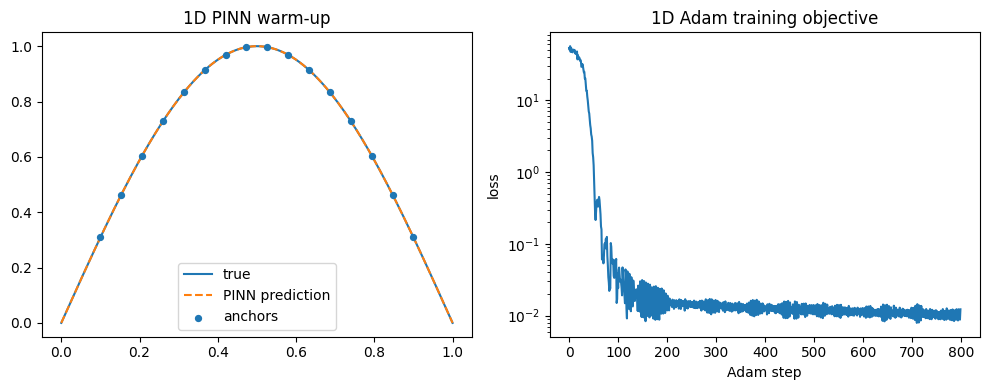

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(x_eval.numpy(), y_true.numpy(), label='true')
axes[0].plot(x_eval.numpy(), y_pred.numpy(), '--', label='PINN prediction')
axes[0].scatter(x_anchor.numpy(), y_anchor.numpy(), s=18, label='anchors', zorder=3)
axes[0].set_title('1D PINN warm-up')
axes[0].legend()

axes[1].plot(history_1d)
axes[1].set_yscale('log')
axes[1].set_title('1D Adam training objective')
axes[1].set_xlabel('Adam step')
axes[1].set_ylabel('loss')
plt.tight_layout()
plt.show()

## 2D main problem

The main case solves

$$
-\Delta u(x,y)=2\pi^2\sin(\pi x)\sin(\pi y),\qquad u=0\;	ext{on the boundary},
$$

with analytic solution $u(x,y)=\sin(\pi x)\sin(\pi y)$.

The important changes relative to the earlier version are:

- anchors are now distributed throughout the interior rather than being clustered
  only near the corners,
- collocation points are resampled during Adam and then frozen for a short LBFGS
  polishing phase,
- the Laplace posterior uses a much larger `prior_precision`, because the PINN
  should remain the main solution and the Bayesian correction should be local,
- `diag` and `block_diag` are both evaluated on the same trained last layer so the
  user can see which approximation perturbs the MAP PINN less. In the current
  configuration, `block_diag` is kept as the displayed uncertainty view because
  it drifts less from the trained MAP solution than `diag`.

This makes the uncertainty map less pathological: the posterior still reflects
lack of direct supervision, but it no longer drifts as aggressively away from the
trained physics-informed solution.

In [4]:
def exact_u(coords):
    return torch.sin(math.pi * coords[:, :1]) * torch.sin(math.pi * coords[:, 1:2])


def forcing(coords):
    return 2.0 * math.pi ** 2 * exact_u(coords)


# Boundary sampling: dense enough that the Dirichlet condition is enforced cleanly.
side = torch.linspace(0.0, 1.0, 24)
zeros = torch.zeros_like(side)
ones = torch.ones_like(side)
boundary = torch.cat([
    torch.stack([side, zeros], dim=1),
    torch.stack([side, ones], dim=1),
    torch.stack([zeros, side], dim=1),
    torch.stack([ones, side], dim=1),
], dim=0).unique(dim=0)

# Interior anchors: a coarse grid plus random interior samples. This is the main
# change requested by the user: the 2D problem should not be constrained only at
# the boundary or in corner-biased regions.
anchor_axis = torch.linspace(0.1, 0.9, 9)
AX, AY = torch.meshgrid(anchor_axis, anchor_axis, indexing='ij')
anchor_grid = torch.stack([AX.reshape(-1), AY.reshape(-1)], dim=1)
anchor_random = torch.rand(64, 2) * 0.8 + 0.1
anchor = torch.cat([anchor_grid, anchor_random], dim=0)


def sample_interior(num_points: int) -> torch.Tensor:
    return torch.rand(num_points, 2)


pinn2d = PINN2D(hidden_dims=(128, 128, 128, 128)).to(device)
adam_2d = torch.optim.Adam(pinn2d.parameters(), lr=1e-3)
history_2d = []

for step in range(1000):
    adam_2d.zero_grad(set_to_none=True)
    xy = sample_interior(1024).to(device).requires_grad_(True)
    u = pinn2d(xy)
    grad = torch.autograd.grad(u.sum(), xy, create_graph=True)[0]
    d2ux = torch.autograd.grad(grad[:, :1].sum(), xy, create_graph=True)[0][:, :1]
    d2uy = torch.autograd.grad(grad[:, 1:].sum(), xy, create_graph=True)[0][:, 1:]
    residual = -(d2ux + d2uy) - forcing(xy)
    loss_pde = (residual ** 2).mean()
    loss_bc = torch.nn.functional.mse_loss(
        pinn2d(boundary.to(device)),
        torch.zeros(boundary.size(0), 1, device=device),
    )
    loss_anchor = torch.nn.functional.mse_loss(
        pinn2d(anchor.to(device)),
        exact_u(anchor.to(device)),
    )
    loss = loss_pde + 25.0 * loss_bc + 25.0 * loss_anchor
    loss.backward()
    torch.nn.utils.clip_grad_norm_(pinn2d.parameters(), max_norm=1.0)
    adam_2d.step()
    history_2d.append(float(loss.detach().cpu()))

# Second-stage LBFGS polish with a larger fixed collocation cloud.
colloc_2d = sample_interior(4096).to(device)
lbfgs_2d = torch.optim.LBFGS(
    pinn2d.parameters(),
    lr=1.0,
    max_iter=120,
    tolerance_grad=1e-9,
    tolerance_change=1e-9,
    history_size=50,
    line_search_fn='strong_wolfe',
)


def closure_2d():
    lbfgs_2d.zero_grad(set_to_none=True)
    xy = colloc_2d.requires_grad_(True)
    u = pinn2d(xy)
    grad = torch.autograd.grad(u.sum(), xy, create_graph=True)[0]
    d2ux = torch.autograd.grad(grad[:, :1].sum(), xy, create_graph=True)[0][:, :1]
    d2uy = torch.autograd.grad(grad[:, 1:].sum(), xy, create_graph=True)[0][:, 1:]
    residual = -(d2ux + d2uy) - forcing(xy)
    loss_pde = (residual ** 2).mean()
    loss_bc = torch.nn.functional.mse_loss(
        pinn2d(boundary.to(device)),
        torch.zeros(boundary.size(0), 1, device=device),
    )
    loss_anchor = torch.nn.functional.mse_loss(
        pinn2d(anchor.to(device)),
        exact_u(anchor.to(device)),
    )
    loss = loss_pde + 25.0 * loss_bc + 25.0 * loss_anchor
    loss.backward()
    return loss

lbfgs_2d.step(closure_2d)

# Fit Laplace only on anchor observations. The scope is already the smallest safe
# one available in the current library: the last linear layer only.
anchor_loader = DataLoader(
    TensorDataset(anchor.float(), exact_u(anchor).float()),
    batch_size=64,
    shuffle=True,
)
prior_precision = 10000.0
backend_models = {}
for backend in ['diag', 'block_diag']:
    la_backend = LaplaceWrapper(
        pinn2d,
        likelihood='regression',
        hessian_structure=backend,
        subset_of_weights='last_layer',
    )
    la_backend.fit(anchor_loader, prior_precision=prior_precision)
    backend_models[backend] = la_backend

selected_backend = 'block_diag'
la = backend_models[selected_backend]

In [5]:
grid = torch.linspace(0.0, 1.0, 50)
GX, GY = torch.meshgrid(grid, grid, indexing='ij')
coords_eval = torch.stack([GX.reshape(-1), GY.reshape(-1)], dim=1)
true_field = exact_u(coords_eval).detach().cpu().reshape(50, 50)
with torch.inference_mode():
    pred_map = pinn2d(coords_eval.to(device)).detach().cpu().reshape(50, 50)

backend_summary = {}
for backend, la_backend in backend_models.items():
    uq_backend = la_backend.predict_uq(coords_eval.float(), n_samples=30)
    mean_backend = uq_backend.mean.detach().cpu().reshape(50, 50)
    std_backend = uq_backend.total_var.sqrt().detach().cpu().reshape(50, 50)
    backend_summary[backend] = {
        'uq': uq_backend,
        'mean_field': mean_backend,
        'std_field': std_backend,
        'laplace_rmse_2d': torch.mean((mean_backend - true_field) ** 2).sqrt().item(),
        'mean_std': std_backend.mean().item(),
    }

mean_field = backend_summary[selected_backend]['mean_field']
std_field = backend_summary[selected_backend]['std_field']
rmse_2d = torch.mean((pred_map - true_field) ** 2).sqrt().item()
laplace_rmse_2d = backend_summary[selected_backend]['laplace_rmse_2d']
print({
    'rmse_2d': rmse_2d,
    'selected_backend': selected_backend,
    'laplace_rmse_2d': laplace_rmse_2d,
    'backend_summary': {
        key: {
            'laplace_rmse_2d': value['laplace_rmse_2d'],
            'mean_std': value['mean_std'],
        }
        for key, value in backend_summary.items()
    },
})

{'rmse_2d': 0.0011061314726248384, 'selected_backend': 'block_diag', 'laplace_rmse_2d': 0.0011061314726248384, 'backend_summary': {'diag': {'laplace_rmse_2d': 0.0011061314726248384, 'mean_std': 0.049027930945158005}, 'block_diag': {'laplace_rmse_2d': 0.0011061314726248384, 'mean_std': 0.0457022599875927}}}


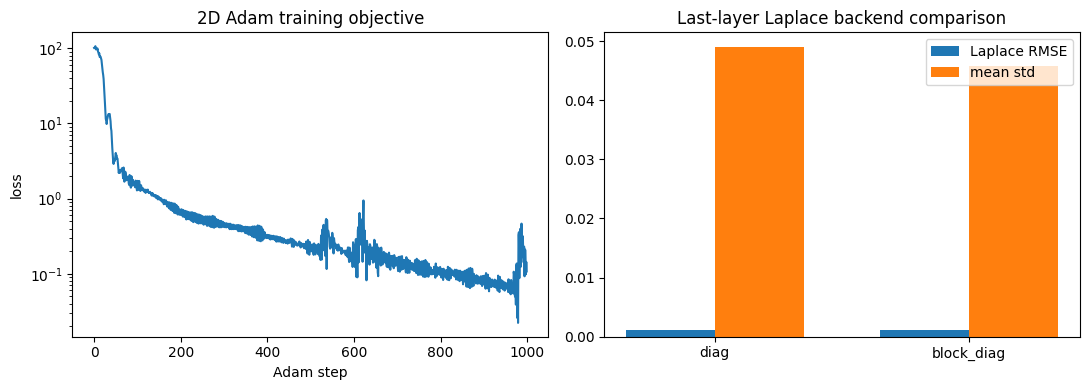

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_2d)
axes[0].set_yscale('log')
axes[0].set_title('2D Adam training objective')
axes[0].set_xlabel('Adam step')
axes[0].set_ylabel('loss')

backend_names = list(backend_summary)
backend_rmses = [backend_summary[name]['laplace_rmse_2d'] for name in backend_names]
backend_stds = [backend_summary[name]['mean_std'] for name in backend_names]
bar_positions = np.arange(len(backend_names))
width = 0.35
axes[1].bar(bar_positions - width / 2, backend_rmses, width=width, label='Laplace RMSE')
axes[1].bar(bar_positions + width / 2, backend_stds, width=width, label='mean std')
axes[1].set_xticks(bar_positions)
axes[1].set_xticklabels(backend_names)
axes[1].set_title('Last-layer Laplace backend comparison')
axes[1].legend()
plt.tight_layout()
plt.show()

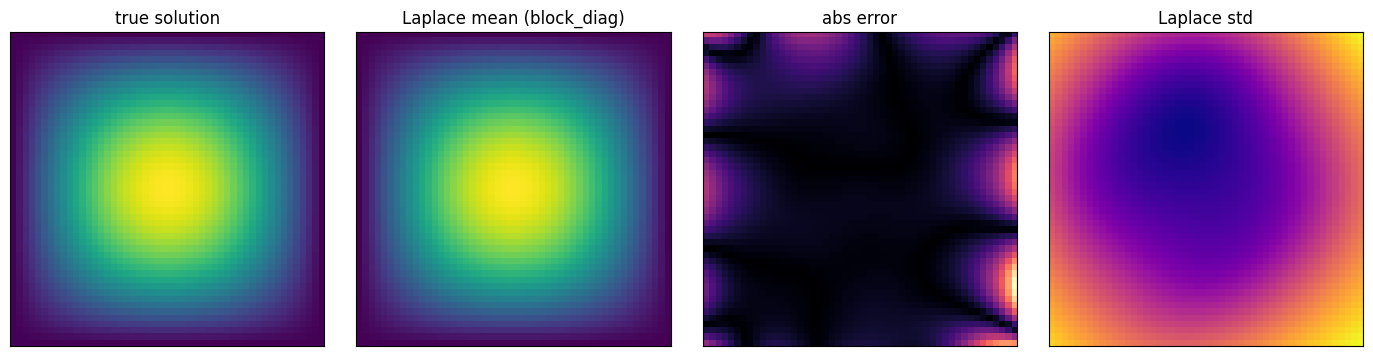

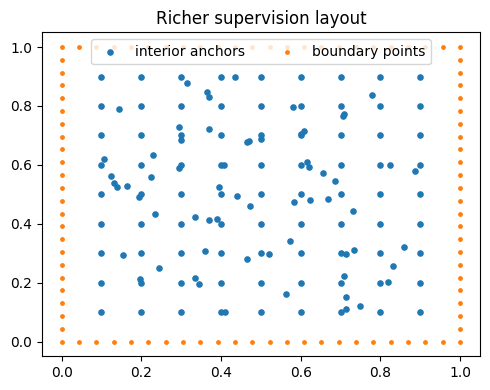

In [7]:
def _to_numpy(field):
    if isinstance(field, torch.Tensor):
        return field.detach().cpu().numpy()
    return field

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, field, title, cmap in [
    (axes[0], true_field, 'true solution', 'viridis'),
    (axes[1], mean_field, f'Laplace mean ({selected_backend})', 'viridis'),
    (axes[2], torch.abs(mean_field - true_field), 'abs error', 'magma'),
    (axes[3], std_field, 'Laplace std', 'plasma'),
]:
    im = ax.imshow(_to_numpy(field), origin='lower', cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.scatter(anchor[:, 0].detach().cpu(), anchor[:, 1].detach().cpu(), s=14, label='interior anchors')
plt.scatter(boundary[:, 0].detach().cpu(), boundary[:, 1].detach().cpu(), s=6, label='boundary points')
plt.title('Richer supervision layout')
plt.legend(loc='upper center', ncol=2)
plt.tight_layout()
plt.show()